<a href="https://colab.research.google.com/github/SemanticApp/quantitative-investment-analysis/blob/main/Quantitative_Investment_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Historical Market Data
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Exploratory Analysis
        ↓
Multiple Regression
        ↓
Train/Test Evaluation
        ↓
Backtesting
        ↓
Monte Carlo Simulation
        ↓
Risk Analysis
        ↓
Investment Comparison
        ↓
Conclusion + Limitations

## **Building and Backtesting a Simple Quantitative Investment Strategy**
**Research Question**

Can commonly available market features—returns, moving-average behavior, volatility, and trading volume—provide useful information for evaluating and forecasting short-term stock returns, and how does that evidence compare with a Monte Carlo view of future outcomes?

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "AAPL"

df = yf.download(
    ticker,
    period="2y",
    auto_adjust=True,
    progress=False
)

# Flatten columns if Yahoo returns a MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df["Return"] = df["Close"].pct_change()

df["MA5"] = (
    df["Close"]
    .rolling(5)
    .mean()
)

df["MA_Distance"] = (
    (df["Close"] - df["MA5"])
    / df["MA5"]
)

df["Volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Tomorrow"] = (
    df["Return"]
    .shift(-1)
)

df = df.dropna()

print(df.head())

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2024-09-17  214.991562  215.100650  212.720566  213.960196   45519300   
2024-09-18  218.859222  220.862469  215.735345  215.745272   59894900   
2024-09-19  226.971313  227.913444  222.766498  223.123512   66781300   
2024-09-20  226.306885  231.156317  225.731695  228.062205  318679900   
2024-09-23  224.591263  227.546537  223.936734  225.454041   54146000   

Price         Return         MA5  MA_Distance  Volatility  Tomorrow  
Date                                                                 
2024-09-17  0.002173  218.381201    -0.015522    0.010822  0.017990  
2024-09-18  0.017990  217.990472     0.003985    0.011676  0.037065  
2024-09-19  0.037065  219.200348     0.035451    0.014485 -0.002927  
2024-09-20 -0.002927  220.330887     0.027123    0.014361 -0.007581  
2024-09-23 -0.007581  222.344049     0.010107    0.014302  0.003974 

## **Figure 1 — Normalized Performance**

Put both investments on a common $100 starting point.

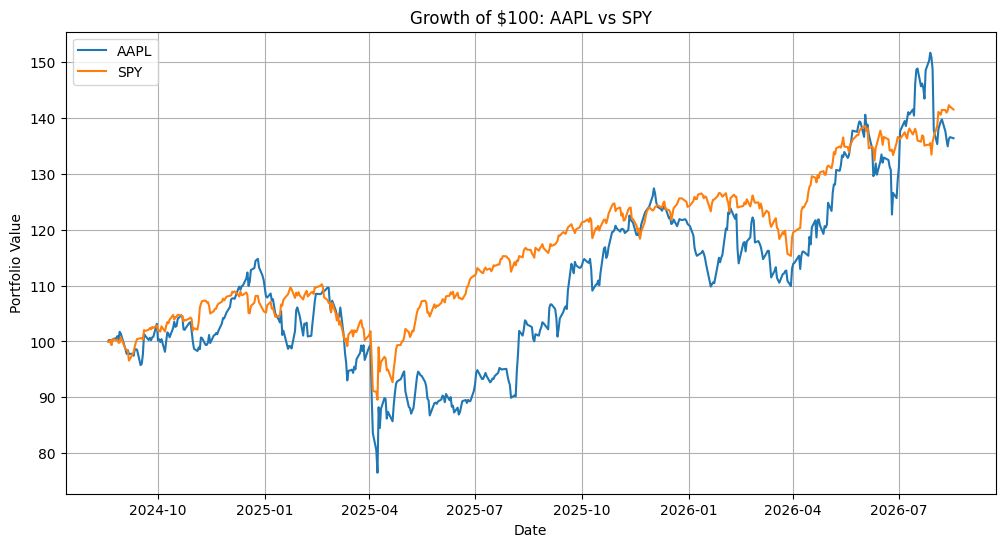

In [2]:
aapl = yf.download(
    "AAPL",
    period="2y",
    auto_adjust=True,
    progress=False
)["Close"]

spy = yf.download(
    "SPY",
    period="2y",
    auto_adjust=True,
    progress=False
)["Close"]

aapl_normalized = aapl / aapl.iloc[0] * 100
spy_normalized = spy / spy.iloc[0] * 100

plt.figure(figsize=(12,6))

plt.plot(aapl_normalized, label="AAPL")
plt.plot(spy_normalized, label="SPY")

plt.title("Growth of $100: AAPL vs SPY")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

## **Figure 2 — Return Distribution**

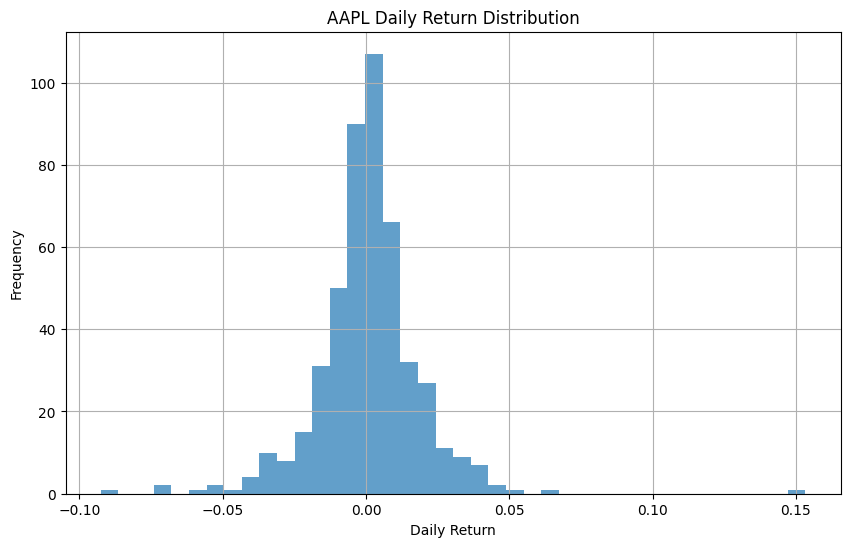

In [3]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Return"],
    bins=40,
    alpha=0.7
)

plt.title("AAPL Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

## **Figure 3 — Rolling Volatility**

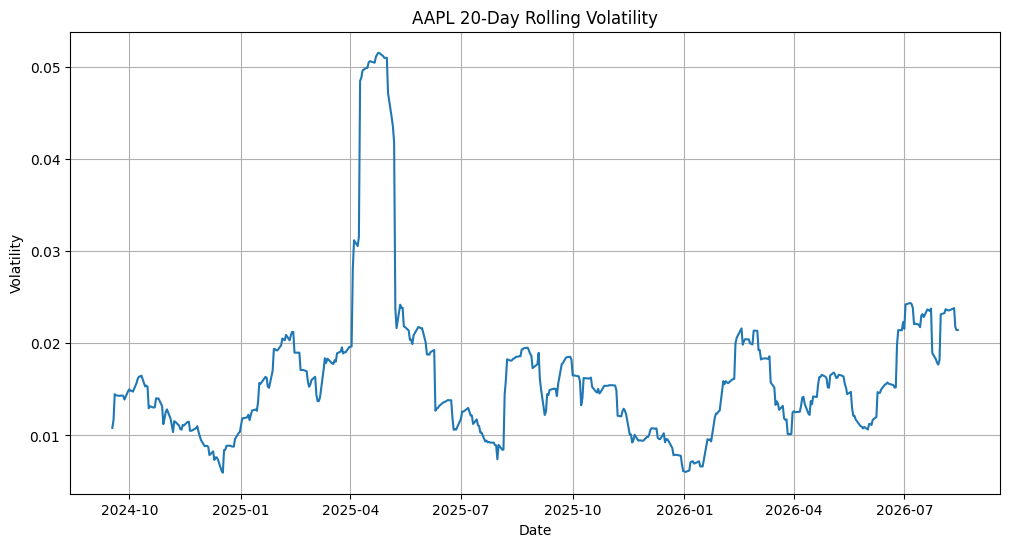

In [4]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df["Volatility"]
)

plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

In [5]:
annual_return = df["Return"].mean() * 252

annual_volatility = (
    df["Return"].std()
    * np.sqrt(252)
)

In [6]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

In [7]:
from sklearn.linear_model import LinearRegression

features = [
    "Return",
    "MA_Distance",
    "Volatility",
    "Volume"
]

X_train = train[features]
y_train = train["Tomorrow"]

X_test = test[features]
y_test = test["Tomorrow"]

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

predictions = model.predict(X_test)

## **Model Evaluation**

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.013472742882833977
RMSE: 0.01848326458425485
R²: -0.017582248384881538


## **Backtesting**

In [9]:
test_results = test.copy()

test_results["Prediction"] = predictions

test_results["Signal"] = (
    test_results["Prediction"] > 0
).astype(int)

test_results["Strategy_Return"] = (
    test_results["Signal"]
    * test_results["Tomorrow"]
)

test_results["Buy_Hold_Return"] = (
    test_results["Tomorrow"]
)

In [10]:
test_results["Strategy_Equity"] = (
    1 + test_results["Strategy_Return"]
).cumprod()

test_results["Buy_Hold_Equity"] = (
    1 + test_results["Buy_Hold_Return"]
).cumprod()

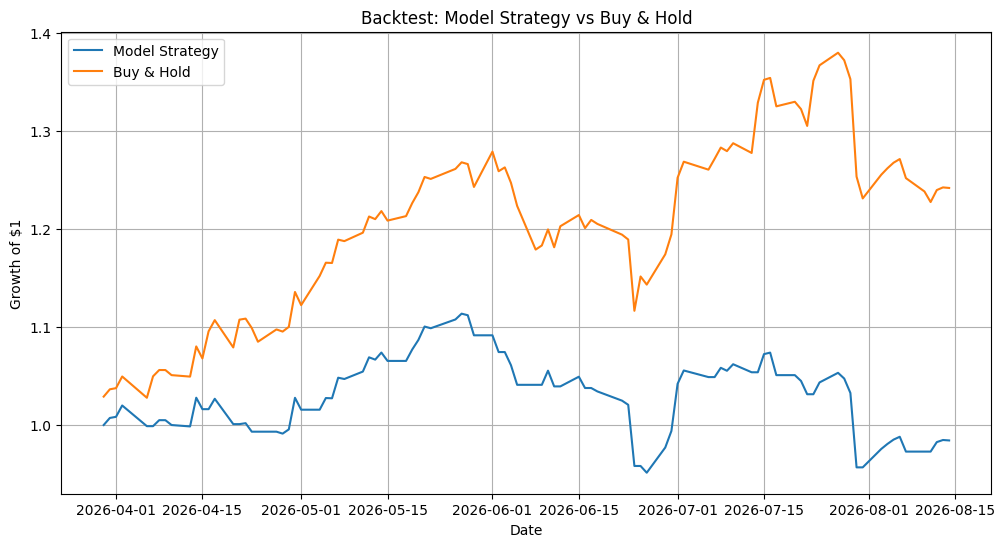

In [11]:
plt.figure(figsize=(12,6))

plt.plot(
    test_results["Strategy_Equity"],
    label="Model Strategy"
)

plt.plot(
    test_results["Buy_Hold_Equity"],
    label="Buy & Hold"
)

plt.title("Backtest: Model Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True)

plt.show()

## **Monte Carlo Simulation**

10,000 simulations × 30 trading days

In [12]:
current_price = df["Close"].iloc[-1]

mu = df["Return"].mean()
sigma = df["Return"].std()

days = 30
simulations = 10000

paths = np.zeros(
    (days + 1, simulations)
)

paths[0] = current_price

for day in range(1, days + 1):

    random_returns = np.random.normal(
        mu,
        sigma,
        simulations
    )

    paths[day] = (
        paths[day - 1]
        * (1 + random_returns)
    )

In [13]:
final_prices = paths[-1]

In [14]:
mean_final = np.mean(final_prices)

median_final = np.median(final_prices)

probability_profit = np.mean(
    final_prices > current_price
)

p5 = np.percentile(
    final_prices,
    5
)

p95 = np.percentile(
    final_prices,
    95
)

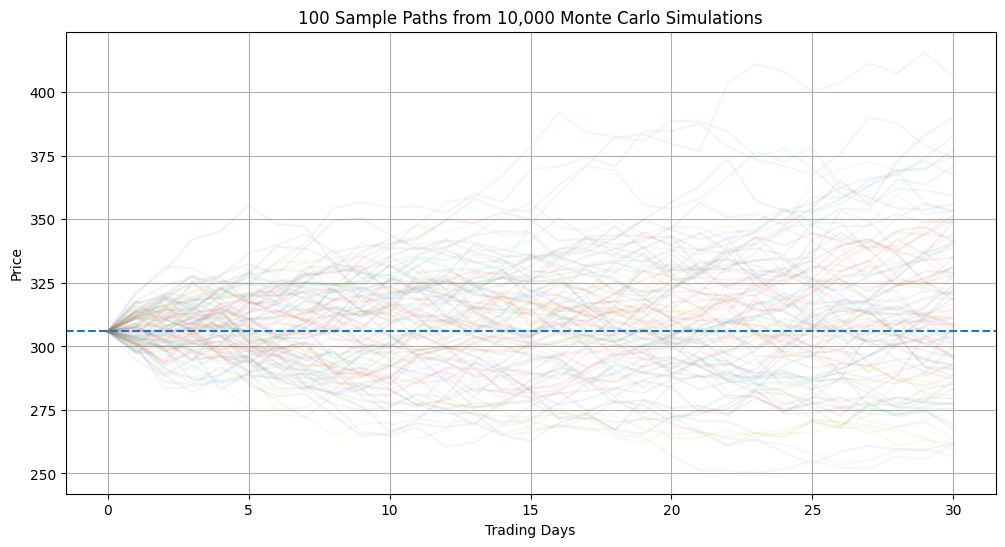

In [15]:
plt.figure(figsize=(12,6))

for i in range(100):
    plt.plot(
        paths[:, i],
        alpha=0.08
    )

plt.axhline(
    current_price,
    linestyle="--"
)

plt.title(
    "100 Sample Paths from 10,000 Monte Carlo Simulations"
)

plt.xlabel("Trading Days")
plt.ylabel("Price")

plt.grid(True)
plt.show()

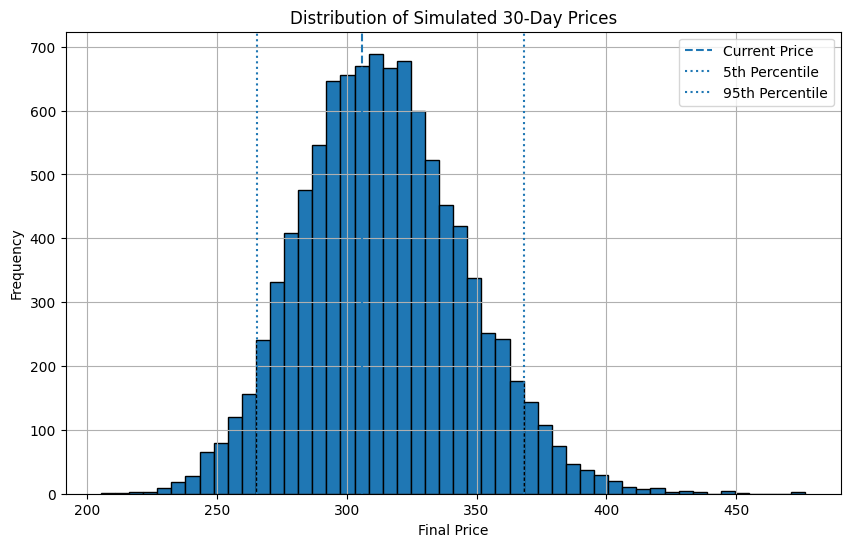

In [16]:
plt.figure(figsize=(10,6))

plt.hist(
    final_prices,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    current_price,
    linestyle="--",
    label="Current Price"
)

plt.axvline(
    p5,
    linestyle=":",
    label="5th Percentile"
)

plt.axvline(
    p95,
    linestyle=":",
    label="95th Percentile"
)

plt.title(
    "Distribution of Simulated 30-Day Prices"
)

plt.xlabel("Final Price")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)

plt.show()